---

### 🎓 **Professor**: Apostolos Filippas

### 📘 **Class**: AI Engineering

### 📋 **Homework 4**: Embeddings & Semantic Search

### 📅 **Due Date**: Day of Lecture 5, 11:59 PM


**Note**: You are not allowed to share the contents of this notebook with anyone outside this class without written permission by the professor.

---

In this homework, you'll build on Homework 3 (BM25 search) by adding **embedding-based semantic search**.

You will:
1. **Generate embeddings** using both local (Hugging Face) and API (OpenAI) models
2. **Implement cosine similarity** from scratch
3. **Implement semantic search** from scratch
4. **Compare BM25 vs semantic search** using Recall
5. **Compare different embedding models** and analyze their differences

**Total Points: 95**

---

## Instructions

- Complete all tasks by filling in code where you see `# YOUR CODE HERE`
- You may use ChatGPT, Claude, documentation, Stack Overflow, etc.
- When using external resources, briefly cite them in a comment
- Run all cells before submitting to ensure they work

**Submission:**
1. Create a branch called `homework-4`
2. Commit and push your work
3. Create a PR and merge to main
4. Submit the `.ipynb` file on Blackboard

---

## Task 1: Environment Setup (10 points)

### 1a. Imports (5 pts)

Import the required libraries and load the WANDS data.

In [1]:
# ruff: noqa: E402

# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings("ignore")

# Import ONLY data loading from helpers
import sys
sys.path.append('../scripts')
from helpers import load_wands_products, load_wands_queries, load_wands_labels

# Embedding libraries - we use these directly
from sentence_transformers import SentenceTransformer
import litellm

# Load environment variables for API keys
from dotenv import load_dotenv
load_dotenv()

pd.set_option('display.max_colwidth', 80)
print("All imports successful!")

All imports successful!


In [16]:


# helpers imports
from helpers import (
    # Data loading
    load_wands_products, load_wands_queries, load_wands_labels,
    # BM25 
    build_index, score_bm25, search_bm25,
    # Evaluation
    evaluate_search,
    # Embeddings
    get_local_model, batch_embed_local,
    # Similarity
    batch_cosine_similarity,
    # Utility
    normalize_scores
)

# Load environment variables for API keys
from dotenv import load_dotenv
load_dotenv()

pd.set_option('display.max_colwidth', 80)
print("All imports successful!")

All imports successful!


In [2]:
# Load the WANDS dataset
products = load_wands_products("data")
queries = load_wands_queries("data")
labels = load_wands_labels("data")

print(f"Products: {len(products):,}")
print(f"Queries: {len(queries):,}")
print(f"Labels: {len(labels):,}")

Products: 42,994
Queries: 480
Labels: 233,448


### 1b. Copy BM25 functions from HW3 (5 pts)

Copy your BM25 implementation from Homework 3. We'll use it to compare against semantic search.

In [3]:
# Copy your BM25 functions from Homework 3

def get_df(term: str, index: dict) -> int:
    """
    Get document frequency for a term.
    
    Args:
        term: The term to look up
        index: The inverted index
        
    Returns:
        Number of documents containing the term
    """
    if term in index:
        return len(index[term])
    return 0

def bm25_idf(df: int, num_docs: int) -> float:
    """
    BM25 IDF formula.
    
    Args:
        df: Document frequency
        num_docs: Total number of documents
        
    Returns:
        IDF score
    """
    return np.log((num_docs - df + 0.5) / (df + 0.5) + 1)

def bm25_tf(tf: int, doc_len: int, avg_doc_len: float, k1: float = 1.2, b: float = 0.75) -> float:
    """
    BM25 TF normalization.
    
    Args:
        tf: Term frequency
        doc_len: Document length in tokens
        avg_doc_len: Average document length
        k1: Saturation parameter (default 1.2)
        b: Length normalization (default 0.75)
        
    Returns:
        Normalized TF score
    """
    return (tf * (k1 + 1)) / (tf + k1 * (1 - b + b * doc_len / avg_doc_len))

def score_bm25(query: str, index: dict, num_docs: int, doc_lengths: list[int], 
               tokenizer, k1: float = 1.2, b: float = 0.75) -> np.ndarray:
    """
    Score all documents using BM25.
    
    Args:
        query: The search query
        index: Inverted index
        num_docs: Total number of documents
        doc_lengths: List of document lengths
        tokenizer: Tokenization function
        
    Returns:
        Array of scores for each document
    """
    query_tokens = tokenizer(query)
    scores = np.zeros(num_docs)
    avg_doc_len = np.mean(doc_lengths) if doc_lengths else 1.0
    
    for token in query_tokens:
        df = get_df(token, index)
        if df == 0:
            continue
        
        idf = bm25_idf(df, num_docs)
        
        if token in index:
            for doc_id, tf in index[token].items():
                tf_norm = bm25_tf(tf, doc_lengths[doc_id], avg_doc_len, k1, b)
                scores[doc_id] += idf * tf_norm
    
    return scores

---

## Task 2: Understanding Embeddings (15 points)

### 2a. Load a local model and generate embeddings (5 pts)

Use `sentence-transformers` to load a local embedding model and generate embeddings for a list of words.

In [4]:
# Load the all-MiniLM-L6-v2 model using SentenceTransformer
# Then generate embeddings for each word in the list
words = ["wooden coffee table", "oak dining table", "red leather sofa", "blue area rug", "kitchen sink"]

# YOUR CODE HERE
model = SentenceTransformer("all-MiniLM-L6-v2")

# Generate embeddings
embeddings = model.encode(words)

# Print results
print("Number of embeddings:", len(embeddings))
print("Embedding dimension:", embeddings.shape[1])


# Print the number of embeddings you generated and the dimension of the embeddings

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 358.68it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Number of embeddings: 5
Embedding dimension: 384


### 2b. Implement cosine similarity and create a similarity matrix (5 pts)

Implement cosine similarity from scratch:

$$\text{cosine\_similarity}(a, b) = \frac{a \cdot b}{\|a\| \times \|b\|}$$

In [6]:
# Implement cosine similarity from scratch
def cosine_similarity_manual(a, b):
    """Calculate cosine similarity between two vectors."""
    dot_product = np.dot(a, b)
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    return dot_product / (norm_a * norm_b)

# Verify it works
sim = cosine_similarity_manual(embeddings[0], embeddings[1])
print(f"Cosine similarity (item 0, item 1): {sim:.6f}")

# Create similarity matrix

# Display as DataFrame


Cosine similarity (item 0, item 1): 0.588631


In [7]:
n = len(words)
similarity_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        similarity_matrix[i, j] = cosine_similarity_manual(
            embeddings[i],
            embeddings[j]
        )

# Display as DataFrame
sim_df = pd.DataFrame(
    similarity_matrix,
    index=words,
    columns=words
)

sim_df

,wooden coffee table,oak dining table,red leather sofa,blue area rug,kitchen sink
wooden coffee table,1.000000,0.588631,0.370622,0.189486,0.295712
oak dining table,0.588631,1.000000,0.337910,0.249521,0.341410
red leather sofa,0.370622,0.337910,1.000000,0.380311,0.057740
blue area rug,0.189486,0.249521,0.380311,1.000000,0.125802
kitchen sink,0.295712,0.341410,0.057740,0.125802,1.000000


### 2c. Embed using OpenAI API (5 pts)

Use `litellm` to get embeddings from OpenAI's API and compare dimensions.

In [8]:
# Use litellm to get an embedding from OpenAI's text-embedding-3-small model
# Compare the dimension with the local model
import litellm

# Get an embedding using OpenAI's API via LiteLLM
# This is what happens inside get_embedding_openai()
response = litellm.embedding(model="text-embedding-3-small", input=["couch"])
couch_emb = np.array(response.data[0]["embedding"])

print("OpenAI embedding dimension:", len(couch_emb))
print("First 10 values:", couch_emb[:10])

# Compare with local model embeddings from 2a (all-MiniLM-L6-v2)
# embeddings = model.encode(words)
print("Local embedding dimension:", embeddings.shape[1])

OpenAI embedding dimension: 1536
First 10 values: [-0.04008757 -0.03272568 -0.02316911  0.01076502 -0.00925792 -0.02412755
 -0.00097753  0.02204399  0.01125119 -0.02878082]
Local embedding dimension: 384


---

## Task 3: Batch Embedding Products (20 points)

### 3a. Embed a product sample (10 pts)

Create a combined text field and embed 5,000 products using the local model.

In [9]:
# Get a consistent sample
products_sample = products.sample(n=5000, random_state=42).reset_index(drop=True)
print(f"Working with {len(products_sample):,} products")
products_sample[['product_id', 'product_name', 'product_class']].head()

Working with 5,000 products


,product_id,product_name,product_class
0,32193,woven wire basket,"Boxes, Bins, Baskets, & Buckets"
1,21379,scallop nightstand,Kids Nightstands
2,42275,ybm home stainless steel colander,"Strainers, Colanders, & Salad Spinners"
3,29885,oneida 2 piece stainless steel strainer set,"Strainers, Colanders, & Salad Spinners"
4,8194,ryland platform bed frame,Bed Frames|Beds


In [10]:
# Create a combined text field (product_name + product_class)
# Then embed all products using model.encode()

# YOUR CODE HERE

products_sample['embed_text'] = (
    products_sample['product_name'].fillna('') + ' ' +
    products_sample['product_class'].fillna('')
)

products_sample['embed_text'].head()

0                                  woven wire basket Boxes, Bins, Baskets, & Buckets
1                                                scallop nightstand Kids Nightstands
2           ybm home stainless steel colander Strainers, Colanders, & Salad Spinners
3    oneida 2 piece stainless steel strainer set Strainers, Colanders, & Salad Sp...
4                                          ryland platform bed frame Bed Frames|Beds
Name: embed_text, dtype: str

In [11]:

# Load local embedding model (reuse from earlier)


product_embeddings = model.encode(
   products_sample['embed_text'].tolist(),
    show_progress_bar=True
)

# Quick sanity check
print("Number of products:", len(product_embeddings))
print("Embedding dimension:", product_embeddings.shape[1])



Batches: 100%|██████████| 157/157 [00:16<00:00,  9.43it/s]

Number of products: 5000
Embedding dimension: 384


### 3b. Save and load embeddings (5 pts)

Save embeddings to a `.npy` file so you don't have to recompute them.

In [12]:
# Save embeddings to ../temp/hw4_embeddings.npy
# Save products_sample to ../temp/hw4_products.csv
# Then load them back and verify they match

np.save('temp/product_embeddings_sample.npy', product_embeddings)
products_sample.to_csv('temp/products_sample.csv', index=False)
print("Saved embeddings and sample to 'scripts/temp/'")

Saved embeddings and sample to 'scripts/temp/'


### 3c. Cost estimation (5 pts)

Estimate the cost to embed all 43K products using OpenAI's API.

**Pricing**: text-embedding-3-small costs ~$0.02 per 1 million tokens.

In [13]:
# Use tiktoken to count actual tokens in the sample
# Then extrapolate to estimate cost for the full dataset
import tiktoken

texts =products_sample['embed_text'].tolist()

encoding = tiktoken.encoding_for_model("text-embedding-3-small")

token_counts = [len(encoding.encode(text)) for text in texts]
total_tokens_sample = sum(token_counts)

print("Total tokens in 5K sample:", total_tokens_sample)

# ---- Extrapolate to 43K products ----
avg_tokens_per_product = total_tokens_sample / len(texts)
estimated_total_tokens = avg_tokens_per_product * 43000

print("Average tokens per product:", round(avg_tokens_per_product, 2))
print("Estimated total tokens for 43K:", int(estimated_total_tokens))

Total tokens in 5K sample: 65077
Average tokens per product: 13.02
Estimated total tokens for 43K: 559662


In [14]:
# ---- Cost calculation ----
cost_per_million = 0.02
estimated_cost = (estimated_total_tokens / 1_000_000) * cost_per_million

print("Estimated embedding cost ($):", round(estimated_cost, 4))

Estimated embedding cost ($): 0.0112


---

## Task 4: Semantic Search (25 points)

### 4a. Implement semantic search (15 pts)

Implement a semantic search function from scratch.

In [20]:
import numpy as np

# words list
words = ["wooden coffee table", "oak dining table", "red leather sofa", "blue area rug", "kitchen sink"]

# embeddings = model.encode(words)  # shape (n, d)

def batch_cosine_similarity(query_vec: np.ndarray, matrix: np.ndarray) -> np.ndarray:
    # cosine = (A·b) / (||A||*||b||) for each row of A
    q = query_vec.astype(float)
    M = matrix.astype(float)

    q_norm = np.linalg.norm(q)
    M_norms = np.linalg.norm(M, axis=1)

    denom = (M_norms * q_norm)
    denom = np.where(denom == 0, 1e-12, denom)  # avoid /0

    return (M @ q) / denom  # shape (n,)

# Stack all embeddings into a matrix
word_matrix = np.array(embeddings)  # (n, d)
print("Matrix shape:", word_matrix.shape)

# Query: choose one item as query (ví dụ "red leather sofa")
query_text = "red leather sofa"
query_idx = words.index(query_text)
query_emb = embeddings[query_idx]

# Calculate similarity to all words at once
similarities = batch_cosine_similarity(query_emb, word_matrix)

for w, sim in zip(words, similarities):
    print(f"{w:20s}: {sim:.4f}")


Matrix shape: (5, 384)
wooden coffee table : 0.3706
oak dining table    : 0.3379
red leather sofa    : 1.0000
blue area rug       : 0.3803
kitchen sink        : 0.0577


In [ ]:
# Implement semantic search
def semantic_search_local(query, product_embeddings, products_df, k=10):
    """Search products using local embedding similarity."""
    # 1. Embed the query
    model = get_local_model("all-MiniLM-L6-v2")
    query_emb = model.encode(query, convert_to_numpy=True)
    
    # 2. Calculate similarity to all products
    similarities = batch_cosine_similarity(query_emb, product_embeddings)
    
    # 3. Get top-k indices
    top_k_idx = np.argsort(-similarities)[:k]
    
    # 4. Build results DataFrame
    results = products_df.iloc[top_k_idx].copy()
    results['similarity'] = similarities[top_k_idx]
    results['rank'] = range(1, k + 1)
    
    return results


,rank,product_name,product_class,similarity
723,1,sofa bed with ottoman,NaN,0.619436
4532,2,"convertible sectional sofa couch , l-shaped couch with modern linen fabric f...",Sectionals,0.596127
4056,3,novogratz brittany 81.5 '' round arm sleeper,Sofas,0.594750
3032,4,simge patio sofa with cushions,Patio Sofas,0.592612
1945,5,bailey 79.5 '' velvet recessed arm sofa,Sofas,0.582845
4768,6,castilloux patio sofa with cushions,Patio Sofas,0.581543
1947,7,garren 52.4 '' square arm loveseat,Sofas,0.578263
2809,8,weinman 91 '' chenille charles of london sofa,Sofas,0.578170
2120,9,kendall sectional sofa with ottoman,Sectionals,0.577216
2676,10,connie 58 '' vegan leather square arm loveseat,Reception Sofas & Loveseats|Sofas,0.577189


In [22]:
# Test semantic search
results = semantic_search_local("couch", product_embeddings, products_sample)
results[['rank', 'product_name', 'product_class', 'similarity']]

,rank,product_name,product_class,similarity
723,1,sofa bed with ottoman,NaN,0.619436
4532,2,"convertible sectional sofa couch , l-shaped couch with modern linen fabric f...",Sectionals,0.596127
4056,3,novogratz brittany 81.5 '' round arm sleeper,Sofas,0.594750
3032,4,simge patio sofa with cushions,Patio Sofas,0.592612
1945,5,bailey 79.5 '' velvet recessed arm sofa,Sofas,0.582845
4768,6,castilloux patio sofa with cushions,Patio Sofas,0.581543
1947,7,garren 52.4 '' square arm loveseat,Sofas,0.578263
2809,8,weinman 91 '' chenille charles of london sofa,Sofas,0.578170
2120,9,kendall sectional sofa with ottoman,Sectionals,0.577216
2676,10,connie 58 '' vegan leather square arm loveseat,Reception Sofas & Loveseats|Sofas,0.577189


### 4b. Evaluate and compare BM25 vs semantic search (10 pts)

Implement Recall@k and compare the two search methods.

In [23]:
# Implement Recall@k

# # Build BM25 index for the sample
sample_index, sample_lengths = build_index(products_sample['product_name'].tolist())

# Search for "sofa" with BM25
bm25_results = search_bm25("sofa", sample_index, products_sample, sample_lengths, k=10)
print("BM25 for 'sofa':")
print(bm25_results[['product_name', 'bm25_score']].to_string())

print("\n" + "="*60 + "\n")

# Search for "sofa" with semantic search
sem_results = semantic_search_local("sofa", product_embeddings, products_sample, k=10)
print("Semantic for 'sofa':")
print(sem_results[['product_name', 'similarity']].to_string())

BM25 for 'sofa':
                          product_name  bm25_score
4769               anibella patio sofa    4.869611
2993               lenville patio sofa    4.869611
3296          chaise lounge floor sofa    4.509064
4046  chafin contemporary leather sofa    4.509064
723              sofa bed with ottoman    4.509064
239       vanetten industrial dog sofa    4.509064
2297            47 '' armless sofa bed    4.509064
4523    kaing patio sofa with cushions    4.198227
3032    simge patio sofa with cushions    4.198227
3258       chloe 74 '' square arm sofa    4.198227


Semantic for 'sofa':
                                       product_name  similarity
723                           sofa bed with ottoman    0.752683
2809  weinman 91 '' chenille charles of london sofa    0.744874
2120            kendall sectional sofa with ottoman    0.735309
3371            samuel 91 '' velvet flared arm sofa    0.734664
3032                 simge patio sofa with cushions    0.728014
1945        bai

In [24]:

sample_product_ids = set(products_sample['product_id'])
sample_labels = labels[labels['product_id'].isin(sample_product_ids)]
sample_query_ids = set(sample_labels['query_id'])
sample_queries = queries[queries['query_id'].isin(sample_query_ids)]

print(f"Queries with products in sample: {len(sample_queries)}")

Queries with products in sample: 473


In [25]:
# Build BM25 index for comparison
print("Evaluating BM25...")
bm25_eval = evaluate_search(
    lambda q: search_bm25(q, sample_index, products_sample, sample_lengths, k=10),
    sample_queries, sample_labels, k=10
)
# Filter queries to those with products in our sample


Evaluating BM25...
Evaluated 473 queries
Mean Recall@10: 0.3559


In [ ]:

print("Evaluating Semantic Search...")
semantic_eval = evaluate_search(
    lambda q: semantic_search_local(q, product_embeddings, products_sample, k=10),
    sample_queries, sample_labels, k=10
)

Evaluating Semantic Search...
Evaluated 473 queries
Mean Recall@10: 0.3253


In [27]:
# Evaluate both BM25 and semantic search on all queries
# Calculate Recall@10 for each method
print("\n" + "="*40)
print("COMPARISON")
print("="*40)
print(f"BM25 Mean Recall@10:     {bm25_eval['recall'].mean():.4f}")
print(f"Semantic Mean Recall@10: {semantic_eval['recall'].mean():.4f}")


COMPARISON
BM25 Mean Recall@10:     0.3559
Semantic Mean Recall@10: 0.3253


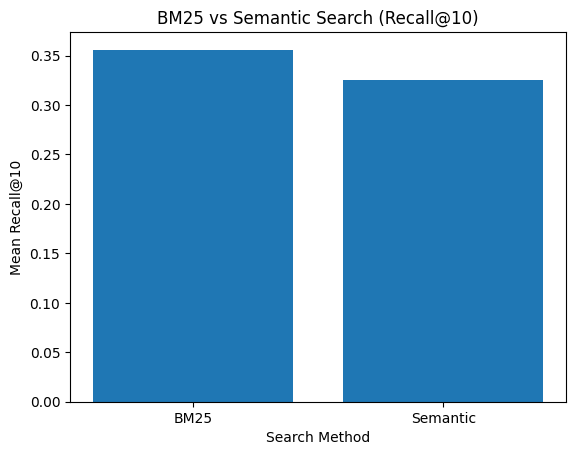

In [34]:
# Visualize comparison

categories = ["BM25", "Semantic"]

# evaluate_search returns a DataFrame with 'recall' column per query
mean_bm25 = bm25_eval["recall"].mean()
mean_sem = semantic_eval["recall"].mean()

values = [mean_bm25, mean_sem]

plt.bar(categories, values)
plt.xlabel("Search Method")
plt.ylabel("Mean Recall@10")
plt.title("BM25 vs Semantic Search (Recall@10)")
plt.show()

---

## Task 5: Compare Embedding Models (20 points)

### 5a. Embed products with two different models (10 pts)

Compare embeddings from:
- `BAAI/bge-base-en-v1.5`
- `sentence-transformers/all-mpnet-base-v2`

In [ ]:
# Load the two embedding models

In [ ]:
# Embed products with both models


### 5b. Compare search results between models (10 pts)

Evaluate both models on the same queries and analyze differences.

In [ ]:
# Compare results for specific queries
test_queries = ["comfortable sofa", "star wars rug", "modern coffee table"]
# add more!

In [ ]:
# Visualize model comparison with a scatter plot
# X-axis: BGE Recall@10, Y-axis: MPNet Recall@10


---

## Task 6: Git Submission (5 points)

Submit your work using the Git workflow:

- [ ] Create a new branch called `homework-4`
- [ ] Commit your work with a meaningful message
- [ ] Push to GitHub
- [ ] Create a Pull Request
- [ ] Merge the PR to main
- [ ] Submit the `.ipynb` file on Blackboard

The TA will verify your submission by checking the merged PR on GitHub.